# Parte 3 — Modelado y Evaluación

En esta sección partimos del dataset preparado en la Parte 2 y entrenamos, comparamos y evaluamos los modelos:

1. Selección de features
2. Baseline y comparativa de modelos
3. Optimización de hiperparámetros
4. Evaluación final contra test
5. Guardado del modelo

Shape del dataset: (46419, 8)

Columnas disponibles:
['disaster_type', 'date', 'latitude', 'longitude', 'depth_km', 'location', 'source', 'es_severo']
Train: 37135 registros (80.0%)
Test:  9284 registros (20.0%)

Proporción de clases en train:
es_severo
0    0.917
1    0.083
Name: proportion, dtype: float64

Proporción de clases en test:
es_severo
0    0.917
1    0.083
Name: proportion, dtype: float64
Tipos de dato:
disaster_type     object
date              object
latitude         float64
longitude        float64
depth_km         float64
location          object
source            object
dtype: object

Duplicados en train: 1

Valores missing en train:
Empty DataFrame
Columns: [Missing, Porcentaje]
Index: []
Shape train tras eliminar duplicados: (37134, 7)
Nuevas features creadas:
       mes   año  cinturon_fuego   prof_grupo
27062   11  2014               0  superficial
1266    11  2000               1  superficial
22005   11  2011               1  superficial
27518    2  2015         

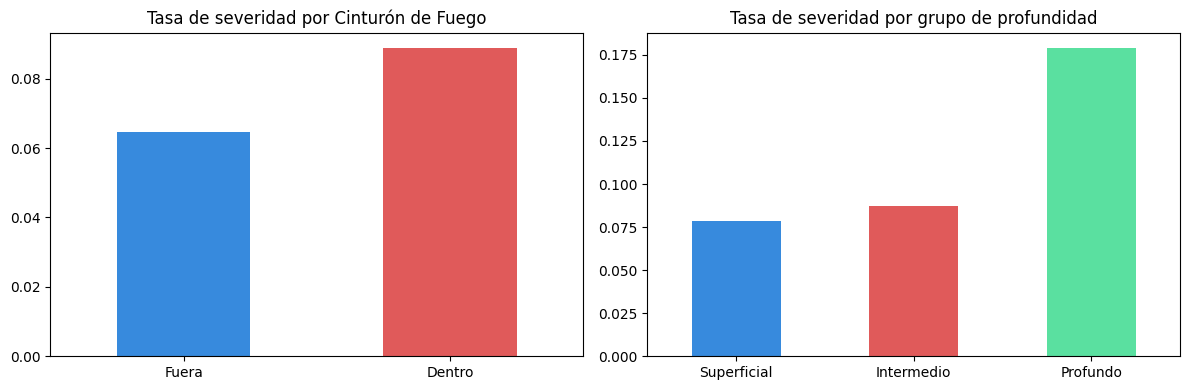

In [2]:
# Cargamos la Parte 2 (preprocesamiento) para heredar X_train, X_test, y_train, y_test
%run ../notebook/02_preprocessing.ipynb

## 1. Selección de Features

Entrenamos un Random Forest para ver qué variables aportan más a la predicción.

In [3]:
from sklearn.ensemble import RandomForestClassifier

# Modelo rápido solo para extraer importancia de features
# class_weight='balanced' compensa el desbalanceo (91.7% / 8.3%)
rf_temp = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_temp.fit(X_train, y_train)

# Importancia de cada variable, ordenada de mayor a menor
importancias = pd.Series(rf_temp.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importancias)

longitude         0.258971
latitude          0.257514
depth_km          0.225822
año               0.134697
mes               0.103459
prof_grupo        0.012271
cinturon_fuego    0.007267
dtype: float64


Mantenemos las 7 features: `latitude`, `longitude` y `depth_km` son las más determinantes; las derivadas (`prof_grupo`, `cinturon_fuego`) aportan poco pero no restan.

## 2. Baseline y Comparativa de Modelos

Empezamos con un baseline simple (DummyClassifier) como referencia mínima, y después comparamos varios modelos con validación cruzada.

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

# Baseline: predice siempre la clase mayoritaria

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

# Evaluamos con F1 (accuracy no sirve por el desbalanceo)

f1_dummy = cross_val_score(dummy, X_train, y_train, cv=5, scoring='f1').mean()
print(f"F1 del baseline (DummyClassifier): {f1_dummy:.4f}")

F1 del baseline (DummyClassifier): 0.0000


El baseline obtiene F1 = 0 al predecir siempre la clase mayoritaria (nunca detecta terremotos severos).

Comparamos 4 modelos con validación cruzada (5-fold), usando F1 como métrica.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Diccionario con los modelos a comparar
# class_weight='balanced' en los que lo soportan, para compensar el desbalanceo

modelos = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier()
}

# Evaluamos cada modelo con CV y guardamos el F1 medio

resultados = {}
for nombre, modelo in modelos.items():
    f1_scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1')
    resultados[nombre] = f1_scores.mean()
    print(f"{nombre}: F1 = {f1_scores.mean():.4f}")

Logistic Regression: F1 = 0.1654
Decision Tree: F1 = 0.1968
Random Forest: F1 = 0.0469
KNN: F1 = 0.0357


Decision Tree obtiene el mejor F1 (0.1968), seguido de Logistic Regression (0.1654). Random Forest y KNN rinden peor: RF por el efecto del promediado de árboles sobre clases desbalanceadas, y KNN por no soportar `class_weight`.

## 3. Optimización de Hiperparámetros

Ajustamos Decision Tree y Logistic Regression con GridSearchCV, ya que fueron los mejores en la comparativa.

In [8]:
from sklearn.model_selection import GridSearchCV

# Rango de hiperparámetros a probar

param_grid_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid_tree,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_tree.fit(X_train, y_train)

print(f"Mejores parámetros (Decision Tree): {grid_tree.best_params_}")
print(f"Mejor F1 (Decision Tree): {grid_tree.best_score_:.4f}")

Mejores parámetros (Decision Tree): {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Mejor F1 (Decision Tree): 0.2397


In [9]:
# Rango de hiperparámetros a probar

param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_log = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid_log,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_log.fit(X_train, y_train)

print(f"Mejores parámetros (Logistic Regression): {grid_log.best_params_}")
print(f"Mejor F1 (Logistic Regression): {grid_log.best_score_:.4f}")

Mejores parámetros (Logistic Regression): {'C': 0.01, 'solver': 'liblinear'}
Mejor F1 (Logistic Regression): 0.1655


El Decision Tree optimizado mejora el F1 de 0.1968 a 0.2397 con `max_depth=5`. Logistic Regression apenas mejora, se mantiene cerca de su rendimiento base. Elegimos el Decision Tree como modelo final.

## 4. Evaluación Final contra Test

Evaluamos el modelo final (Decision Tree optimizado) contra el conjunto de test.

F1 en test: 0.2543
ROC-AUC en test: 0.6808

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.76      0.84      8510
           1       0.17      0.53      0.25       774

    accuracy                           0.74      9284
   macro avg       0.56      0.65      0.55      9284
weighted avg       0.88      0.74      0.79      9284



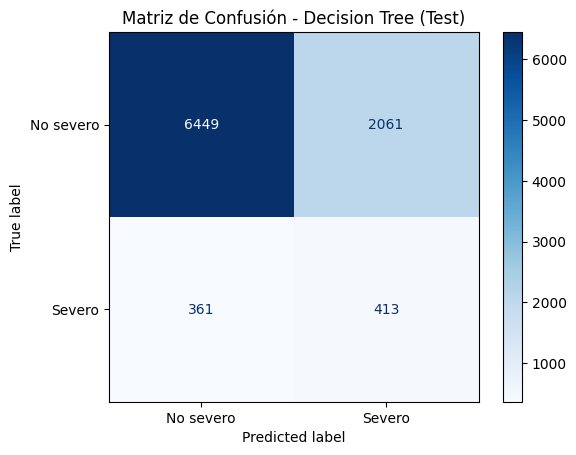

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, f1_score, classification_report

# Modelo final ya entrenado por GridSearchCV con los mejores parámetros

modelo_final = grid_tree.best_estimator_

# Predicciones sobre test

y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

# Métricas

f1_test = f1_score(y_test, y_pred)
roc_auc_test = roc_auc_score(y_test, y_proba)

print(f"F1 en test: {f1_test:.4f}")
print(f"ROC-AUC en test: {roc_auc_test:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No severo', 'Severo'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Decision Tree (Test)')
plt.show()

El modelo detecta el 53% de los terremotos severos (recall), a costa de una precisión baja (17%) por las falsas alarmas. Dado el contexto de alerta temprana, priorizar el recall sobre la precisión es una decisión razonable: es preferible una falsa alarma que no detectar un terremoto severo.

## Ajuste del Umbral de Decisión

Probamos distintos umbrales de probabilidad para ver si mejoramos el F1 respecto al umbral por defecto (0.5).

In [13]:
from sklearn.metrics import f1_score

# Probamos distintos umbrales sobre las probabilidades ya calculadas
umbrales = np.arange(0.1, 0.85, 0.05)
resultados_umbral = []

for u in umbrales:
    y_pred_u = (y_proba >= u).astype(int)
    f1_u = f1_score(y_test, y_pred_u)
    resultados_umbral.append(f1_u)
    print(f"Umbral {u:.2f}: F1 = {f1_u:.4f}")

# Umbral que maximiza F1
mejor_umbral = umbrales[np.argmax(resultados_umbral)]
print(f"\nMejor umbral: {mejor_umbral:.2f} (F1 = {max(resultados_umbral):.4f})")

Umbral 0.10: F1 = 0.1538
Umbral 0.15: F1 = 0.1538
Umbral 0.20: F1 = 0.1538
Umbral 0.25: F1 = 0.1588
Umbral 0.30: F1 = 0.1844
Umbral 0.35: F1 = 0.1844
Umbral 0.40: F1 = 0.1923
Umbral 0.45: F1 = 0.2289
Umbral 0.50: F1 = 0.2543
Umbral 0.55: F1 = 0.2572
Umbral 0.60: F1 = 0.2654
Umbral 0.65: F1 = 0.2677
Umbral 0.70: F1 = 0.2677
Umbral 0.75: F1 = 0.1186
Umbral 0.80: F1 = 0.1186

Mejor umbral: 0.65 (F1 = 0.2677)


El umbral óptimo es 0.65 (F1 = 0.2677), ligera mejora sobre el umbral por defecto (0.5 → F1 = 0.2543). Recalculamos las métricas finales con este umbral.

F1 en test (umbral 0.65): 0.2677
ROC-AUC en test: 0.6808

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      8510
           1       0.21      0.37      0.27       774

    accuracy                           0.83      9284
   macro avg       0.57      0.62      0.59      9284
weighted avg       0.88      0.83      0.85      9284



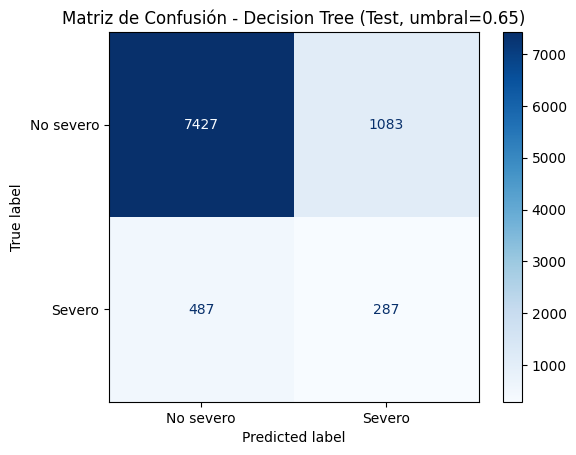

In [14]:
# Aplicamos el umbral óptimo encontrado
umbral_optimo = 0.65
y_pred_ajustado = (y_proba >= umbral_optimo).astype(int)

f1_final = f1_score(y_test, y_pred_ajustado)
roc_auc_final = roc_auc_score(y_test, y_proba)  # ROC-AUC no depende del umbral

print(f"F1 en test (umbral {umbral_optimo}): {f1_final:.4f}")
print(f"ROC-AUC en test: {roc_auc_final:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ajustado))

cm_ajustada = confusion_matrix(y_test, y_pred_ajustado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ajustada, display_labels=['No severo', 'Severo'])
disp.plot(cmap='Blues')
plt.title(f'Matriz de Confusión - Decision Tree (Test, umbral={umbral_optimo})')
plt.show()

## Decisión sobre el Umbral

Aunque el umbral 0.65 da un F1 ligeramente superior (0.2677 vs 0.2543), reduce el recall de la clase "Severo" de 53% a 37% — es decir, detecta menos terremotos severos reales.

En un sistema de alerta temprana, es preferible asumir más falsas alarmas que dejar pasar terremotos severos sin avisar. Por eso mantenemos el umbral por defecto (0.5), que prioriza el recall sobre la precisión.

## Exploración con SMOTE

Probamos si generar ejemplos sintéticos de la clase minoritaria con SMOTE mejora el recall de los terremotos severos.

In [15]:
from imblearn.over_sampling import SMOTE

# Generamos ejemplos sintéticos de la clase minoritaria solo en train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribución original en train: {y_train.value_counts().to_dict()}")
print(f"Distribución tras SMOTE: {y_train_smote.value_counts().to_dict()}")

# Reentrenamos el Decision Tree con los mismos hiperparámetros óptimos, pero con datos balanceados
modelo_smote = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=2, random_state=42)
modelo_smote.fit(X_train_smote, y_train_smote)

# Evaluamos contra el mismo test de siempre (sin tocar)
y_pred_smote = modelo_smote.predict(X_test)
f1_smote = f1_score(y_test, y_pred_smote)

print(f"\nF1 en test (con SMOTE): {f1_smote:.4f}")
print("\nClassification Report (con SMOTE):")
print(classification_report(y_test, y_pred_smote))

Distribución original en train: {0: 34038, 1: 3096}
Distribución tras SMOTE: {0: 34038, 1: 34038}

F1 en test (con SMOTE): 0.2276

Classification Report (con SMOTE):
              precision    recall  f1-score   support

           0       0.95      0.67      0.79      8510
           1       0.14      0.59      0.23       774

    accuracy                           0.67      9284
   macro avg       0.54      0.63      0.51      9284
weighted avg       0.88      0.67      0.74      9284



SMOTE mejora el recall de la clase Severo (59% vs 53%), a costa de un F1 global algo menor (0.2276 vs 0.2543) por el aumento de falsas alarmas sobre la clase mayoritaria. 

Dado que el objetivo es un sistema de alerta temprana, donde es preferible una falsa alarma a no detectar un terremoto severo, nos quedamos con el modelo entrenado con SMOTE como modelo final.

## 5. Guardado del Modelo

In [16]:
import joblib

# Guardamos el modelo con SMOTE, mejor recall para detección de terremotos severos
joblib.dump(modelo_smote, '../models/decision_tree_sismicidad.joblib')
print("Modelo guardado en src/models/decision_tree_sismicidad.joblib")

Modelo guardado en src/models/decision_tree_sismicidad.joblib
